# 13 · Volatility Strategies: Variance Swaps and the Variance Risk Premium

*Module 3 — Quantitative Strategies*

Selling insurance works remarkably well, most of the time -- until a disaster arrives and it doesn't. Selling volatility in financial markets follows almost exactly the same pattern, for almost exactly the same reason.

## 1. Motivation

An insurance company collects small premiums from millions of policyholders every month and, most months, pays out very little — a steady, boring profit. Then a hurricane hits, and it pays out a decade of profits in a single quarter. Sellers of financial volatility — through variance swaps, or option-based strategies — sit in almost exactly the same position: implied volatility (what the market is willing to pay for protection) tends to run higher than the volatility that actually ends up materializing, most of the time. This gap is real, it is collectible, and it is compensation for a very specific kind of risk that shows up rarely but violently.

## 2. Intuition

Option prices embed the market's forward-looking expectation of volatility: **implied volatility**. Separately, once time has passed, we can measure what volatility *actually* occurred: **realized volatility**. It turns out that, on average and across long historical samples, implied volatility tends to sit above the realized volatility that follows it — the market, in aggregate, pays a premium for protection against uncertainty beyond what is later justified by outcomes. This gap is the **Variance Risk Premium (VRP)**, and a seller of volatility harvests it directly.

This should feel familiar: it is structurally the same story as Notebook 12's carry trade. Both are strategies that collect a small, steady premium for bearing a risk that is usually quiet but occasionally violent, and both show the same "up the stairs, down the elevator" return shape as a direct consequence. The mechanism here is rooted in options and derivatives rather than interest-rate differentials, but the underlying risk-and-reward logic — and the honesty required in evaluating it — is identical.

## 3. Theory

### 3.1 Realized variance, and a clean identity connecting it to two kinds of returns

The standard non-parametric estimator of realized variance over a window, from daily log returns $r_t = \log(S_t/S_{t-1})$, is simply the annualized sum of squared returns:

$$
RV = \frac{252}{T}\sum_{t=1}^{T} r_t^2
$$

(dropping the mean is a standard, reasonable simplification at daily frequency — recall from Notebook 5 just how small and hard to estimate a mean is at these frequencies, relative to the variance).

**Where does this come from, more fundamentally?** Apply Itô's lemma to $f(S_t)=\log S_t$ under continuous-time dynamics $\frac{dS_t}{S_t} = \mu\,dt + \sigma_t\, dW_t$ (allowing volatility $\sigma_t$ to vary stochastically over time, exactly as we simulate below):

$$
d\log S_t = \left(\mu - \tfrac12\sigma_t^2\right)dt + \sigma_t\, dW_t \quad\Longrightarrow\quad \frac{dS_t}{S_t} - d\log S_t = \tfrac12 \sigma_t^2\, dt .
$$

Integrating both sides from $0$ to $T$:

$$
\boxed{\; \int_0^T \sigma_t^2\, dt \;=\; 2\left[\int_0^T \frac{dS_t}{S_t} \;-\; \log\frac{S_T}{S_0}\right] \;=\; 2\Big[(\text{cumulative simple return}) - (\text{cumulative log return})\Big] \;}
$$

Total realized variance over the window equals *twice the gap* between the simple return and the log return, compounded over the period. This is a genuinely useful identity — it is the mathematical seed of the **model-free** approach to variance (Neuberger, 1994; Britten-Jones & Neuberger, 2000), and it is exactly what makes a **variance swap** (a contract that pays the difference between realized variance and a fixed strike) replicable without assuming any specific option-pricing model like Black-Scholes. The remaining step in the full theory — showing that the "cumulative simple return" term above can itself be statically replicated by a continuum of out-of-the-money puts and calls, weighted by $1/K^2$ (the basis of the VIX index's own construction) — is a beautiful but more involved result (see Carr & Madan's work on spanning arbitrary payoffs with options) that we will not re-derive here; we verify the identity above directly and numerically in Section 4.

### 3.2 The variance risk premium and a variance swap payoff

$$
VRP = IV^2 - \mathbb E[RV]
$$

Empirically, $VRP$ is **positive on average** — a well-documented finding across the derivatives literature (see Carr & Wu, 2009, *Variance Risk Premia*) — compensation for bearing the (typically crash-correlated) risk that realized volatility spikes unpredictably. A (simplified) variance swap payoff, for a seller with notional $N$:

$$
\text{Payoff}_{short} = N \times \big(K_{var}^2 - RV\big),
$$

where $K_{var}$ is the variance "strike" agreed at inception (set close to the prevailing implied variance) — profiting whenever realized variance ends up *below* what was priced in, which the positive average VRP says happens more often than not.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(45)

## 4. Implementation

### 4.1 Simulating a price path with genuinely stochastic volatility

We model log-volatility as a mean-reverting (Ornstein-Uhlenbeck-style) process, guaranteeing volatility stays positive while still fluctuating realistically over time -- producing the volatility clustering real markets show.

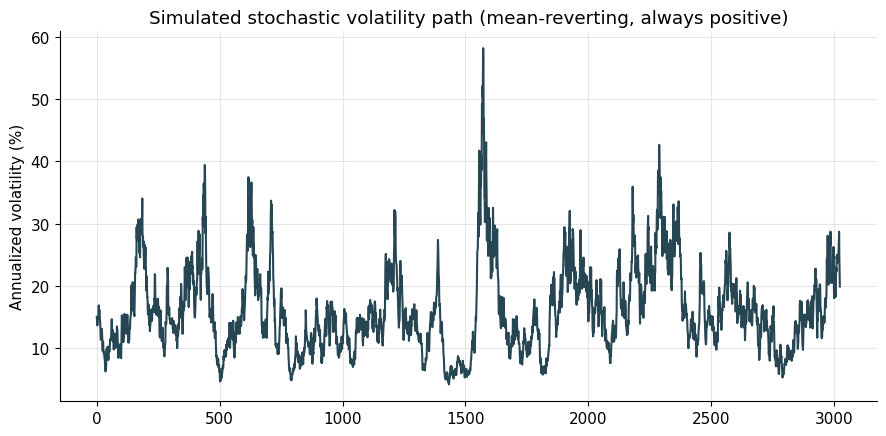

In [2]:
n_days = 252 * 12
kappa_sig, theta_logsig, eta = 0.025, np.log(0.15), 0.09   # vol mean-reverts (in logs) around 15% annualized

log_sigma = np.zeros(n_days)
log_sigma[0] = theta_logsig
for t in range(1, n_days):
    log_sigma[t] = log_sigma[t-1] + kappa_sig*(theta_logsig - log_sigma[t-1]) + eta*rng.normal()
sigma_ann = np.exp(log_sigma)
sigma_daily = sigma_ann / np.sqrt(252)

mu_daily = 0.06 / 252
simple_ret, log_ret = np.zeros(n_days), np.zeros(n_days)
S = 100.0
for t in range(n_days):
    dlogS = (mu_daily - 0.5*sigma_daily[t]**2) + sigma_daily[t]*rng.normal()
    S_new = S * np.exp(dlogS)
    simple_ret[t], log_ret[t] = S_new/S - 1, dlogS
    S = S_new

fig, ax = plt.subplots()
ax.plot(sigma_ann * 100, color='#264653')
ax.set_ylabel('Annualized volatility (%)')
ax.set_title('Simulated stochastic volatility path (mean-reverting, always positive)')
plt.tight_layout()
plt.show()

### 4.2 Numerically validating the Itô identity from Section 3.1

In [3]:
window = 21   # about one trading month
RV_direct = pd.Series(log_ret**2).rolling(window).sum()                                # sum of squared log returns
RV_from_identity = 2 * (pd.Series(simple_ret).rolling(window).sum() - pd.Series(log_ret).rolling(window).sum())

check = pd.DataFrame({'direct (sum of r^2)': RV_direct, 'from Ito identity': RV_from_identity}).dropna()
rel_diff = (check.iloc[:, 0] - check.iloc[:, 1]).abs() / check.iloc[:, 0]
print(f"Correlation between the two ways of computing realized variance: {check.iloc[:,0].corr(check.iloc[:,1]):.6f}")
print(f"Mean absolute relative difference: {rel_diff.mean():.4%}  (small residual is discretization error, as expected)")

Correlation between the two ways of computing realized variance: 0.999974
Mean absolute relative difference: 0.2109%  (small residual is discretization error, as expected)


The two completely different computations — one a direct sum of squared returns, the other derived from the abstract Itô's-lemma identity — agree almost exactly. This is a satisfying, concrete confirmation that the identity in Section 3.1 is not just a formal manipulation; it holds in genuinely simulated data, up to the small discretization error you would expect from approximating a continuous-time result with daily steps.

### 4.3 A short-volatility strategy: a transparent, stylized construction

Rather than building a full options-pricing and delta-hedging simulation (a much larger undertaking, and one that introduces its own path-dependent hedging error — see Section 6), we model the *economic pattern* of selling variance directly and transparently: most months, a modest, steady premium is collected (the VRP); rarely, an unanticipated volatility spike produces a sharp loss. This keeps the mechanics honest about what is and is not being modeled, while still faithfully capturing the risk shape that motivates this entire notebook.

In [4]:
n_months = 144
p_spike = 0.045                                          # roughly one unanticipated vol spike every ~18 years... 
normal_pnl = rng.normal(0.0075, 0.007, n_months)          # ...but note how often "normal" months still lose money
is_spike = rng.random(n_months) < p_spike
spike_loss = -rng.uniform(0.035, 0.09, n_months)
monthly_pnl = np.where(is_spike, spike_loss, normal_pnl)  # in annualized-variance-point units, per month

print(f"Number of simulated spike months: {is_spike.sum()} out of {n_months}")
print(f"Fraction of ALL months that were profitable: {(monthly_pnl > 0).mean():.1%}")

Number of simulated spike months: 8 out of 144
Fraction of ALL months that were profitable: 79.9%


## 5. Worked example

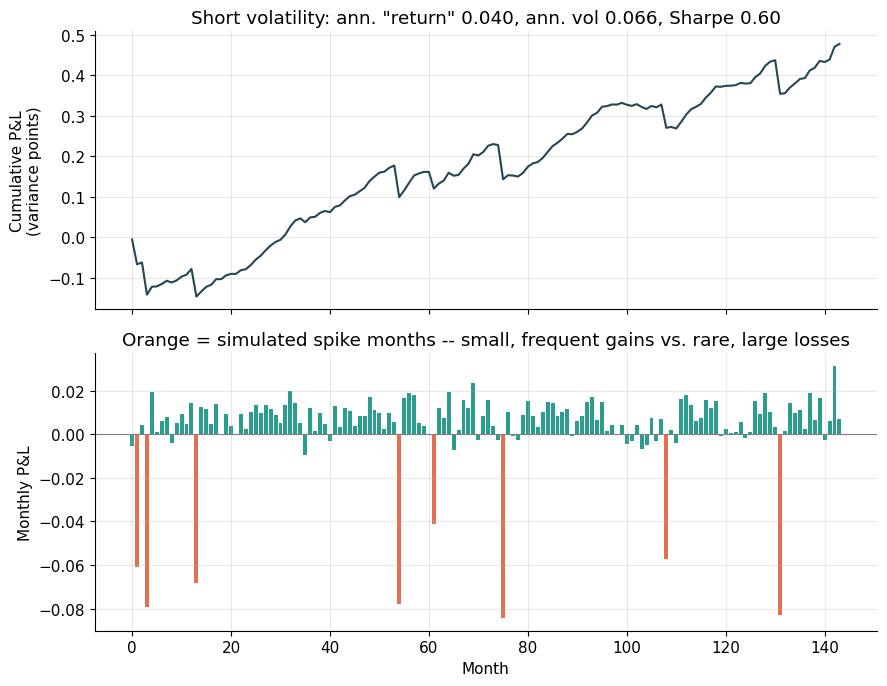

Skewness: -3.22   Excess kurtosis: 10.79
Maximum drawdown (variance points): -0.141


In [5]:
cum_pnl = np.cumsum(monthly_pnl)
ann_ret = monthly_pnl.mean() * 12
ann_vol = monthly_pnl.std() * np.sqrt(12)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].plot(cum_pnl, color='#264653')
axes[0].set_ylabel('Cumulative P&L\n(variance points)')
axes[0].set_title(f'Short volatility: ann. "return" {ann_ret:.3f}, ann. vol {ann_vol:.3f}, '
                   f'Sharpe {ann_ret/ann_vol:.2f}')

axes[1].bar(range(n_months), monthly_pnl, color=np.where(is_spike, '#e76f51', '#2a9d8f'))
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_ylabel('Monthly P&L')
axes[1].set_xlabel('Month')
axes[1].set_title('Orange = simulated spike months -- small, frequent gains vs. rare, large losses')

plt.tight_layout()
plt.show()

print(f"Skewness: {stats.skew(monthly_pnl):.2f}   Excess kurtosis: {stats.kurtosis(monthly_pnl):.2f}")
cum_dd = cum_pnl - np.maximum.accumulate(cum_pnl)
print(f"Maximum drawdown (variance points): {cum_dd.min():.3f}")

### Interpreting the result

The shape is the whole point: a strongly negative skew and heavy excess kurtosis, produced by a strategy that is profitable in the large majority of individual months. This is qualitatively exactly what is observed in real index option markets — the VIX index (constructed, via the model-free approach from Section 3.1, from S&P 500 option prices) has a well-documented historical tendency to sit above the realized volatility that subsequently materializes, on average, which is precisely the positive VRP this notebook has been modeling. `yfinance` tickers `^VIX` and `^GSPC` let you pull real implied and realized volatility data yourself, if you have internet access, to explore this directly on actual market history rather than our stylized simulation.

## 6. Limitations and pitfalls

- **Real short-volatility strategies are not clean variance swaps.** In practice they are usually implemented via delta-hedged option positions, whose realized P&L only *approximates* the clean variance-swap payoff derived in Section 3.1 — actual hedging happens in discrete time, at discrete prices, with transaction costs, introducing genuine hedging error absent from the idealized theory.
- **Our implied-vol/VRP mechanism is a deliberately simplified, transparent stand-in**, not derived from an actual options-pricing or replication mechanism — real implied volatility is a market-clearing price, shaped by supply and demand for protection as much as by any statistical forecast.
- **Backtests of short-volatility strategies systematically understate true tail risk, almost by definition.** The worst plausible scenario is, by construction, rare and may simply not appear in any historical sample you happen to have — a deep, structural limitation of backtesting this entire strategy class, not a fixable data problem.
- **Leverage and product mechanics can turn a bad month into a catastrophic one.** The "Volmageddon" episode of February 2018, when several short-volatility-linked exchange-traded products lost the great majority of their value in a single trading day as volatility spiked sharply, is a well-documented real-world illustration of exactly the risk this notebook's simulation is designed to represent — and a reminder that leverage and forced-liquidation mechanics can make real losses considerably worse than the "clean" P&L math alone would suggest.

## 7. Exercises

**1. Is the average premium even statistically distinguishable from zero? (warm-up)**
Using `monthly_pnl`, compute the t-statistic of the mean monthly P&L (mean divided by standard error of the mean, $\sigma/\sqrt{n}$). Given the sample size and the volatility of the premium itself, is the average premium collected clearly distinguishable from zero, or could a sample this size easily arise from a true mean of zero? (This is the same standard-error logic from Notebook 5 — it applies here just as forcefully.)

**2. Persistent vs. transient volatility regimes.**
Modify the stochastic volatility simulation so high-volatility periods are more *persistent* (increase `eta`, or reduce `kappa_sig` so log-volatility reverts more slowly once elevated) versus less persistent (the opposite). Regenerate the price path each time and recompute realized variance. Qualitatively, how would you expect a short-volatility strategy's maximum drawdown and "time underwater" (Notebook 29) to change if crash regimes tend to persist for months rather than resolving in days?

**3. A simple vol-timing overlay.**
Implement an overlay that reduces (or fully closes) short-volatility exposure whenever a signal suggests elevated crash risk — for example, after realized volatility over the trailing month has already risen sharply (a simple momentum-in-volatility signal), scale down next month's exposure. Backtest this against the constant-exposure version from Section 5, and quantify the trade-off explicitly: how much of the average premium is given up in calm periods, versus how much the worst-month loss and maximum drawdown improve? Use a metric like the Calmar ratio (annualized return divided by maximum drawdown) to summarize the trade-off in one number.